# Duailty, Equality-Constrained Newton, Interior-Point Method

1. **duality**: 왜 dual function이 lower bound를 주는가  
2. **KKT + Newton**: 왜 equality-constrained Newton step이 핵심 linear system이 되는가  
3. **barrier / primal-dual interior point**: 왜 interior-point method가 Newton method의 자연스러운 확장인가  

즉, 오늘의 큰 줄기는

$\text{duality} \;\longrightarrow\; \text{KKT system} \;\longrightarrow\; \text{Newton step} \;\longrightarrow\; \text{barrier} \;\longrightarrow\; \text{primal-dual IPM}$

입니다.

In [2]:
import os
import sys
import math
import importlib
import subprocess
import warnings

required_packages = ["cvxpy", "pandas", "matplotlib"]
missing_packages = [pkg for pkg in required_packages if importlib.util.find_spec(pkg) is None]
if missing_packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing_packages])

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp
from IPython.display import display

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.dpi"] = 120
rng = np.random.default_rng(7)

def solve_problem(problem, solvers=("CLARABEL", "SCS", "SCIPY")):
    last_error = None
    for solver in solvers:
        if solver in cp.installed_solvers():
            try:
                value = problem.solve(solver=solver, verbose=False)
                if problem.status in ("optimal", "optimal_inaccurate"):
                    return value, solver
            except Exception as exc:
                last_error = exc
    raise RuntimeError(f"Could not solve the problem. Last error: {last_error}")

def make_grid(xlim, ylim, n=300):
    x = np.linspace(xlim[0], xlim[1], n)
    y = np.linspace(ylim[0], ylim[1], n)
    return np.meshgrid(x, y)

## Part 0. 전체 지도: 세 노트북을 어떻게 하나로 읽을 것인가?

우리가 계속 다룰 일반형은

\begin{aligned}
\min_x \quad & f(x) \\
\text{subject to}\quad & h_i(x)\le 0,\quad i=1,\dots,m,\\
& Ax=b
\end{aligned}

입니다.

이때 중요한 질문은 다음과 같습니다.

1. **duality**: 이 문제의 dual function은 어떤 lower bound를 주는가?  
2. **KKT**: 최적점에서는 어떤 stationarity / feasibility / complementary slackness가 성립하는가?  
3. **Newton**: KKT system을 선형화하면 어떤 update direction이 나오는가?  
4. **barrier**: inequality constraint를 log barrier로 옮기면 어떤 smooth |problem이 생기는가?  
5. **primal-dual IPM**: barrier의 outer loop와 Newton의 inner loop를 한 번에 합칠 수 있는가?  

이 순서를 머릿속에 두고 보면, 뒤의 알고리즘은 앞의 개념을 “재사용”하는 방식으로 등장합니다.

### 오늘 계속 반복해서 볼 세 가지 식

#### 1. Lagrangian

$L(x,\lambda,\nu) = f(x) + \sum_{i=1}^m \lambda_i h_i(x) + \nu^\top (Ax-b)$


#### 2. Dual function
$g(\lambda,\nu) = \inf_x L(x,\lambda,\nu)$

#### 3. KKT conditions

\begin{aligned}
\nabla f(x^\star) + \sum_i \lambda_i^\star \nabla h_i(x^\star) + A^\top \nu^\star &= 0,\\
h_i(x^\star)\le 0,\quad Ax^\star=b,\quad \lambda_i^\star &\ge 0,\\
\lambda_i^\star h_i(x^\star) &= 0
\end{aligned}


Part 1에서는 이 식들이 **왜 중요한 lower bound와 certificate를 주는지** 보고,  
Part 2에서는 equality-constrained Newton을 통해 **KKT linear system을 직접 푸는 방법**을 보고,  
Part 3–4에서는 inequality constraint가 있는 문제를 **barrier / primal-dual**로 확장합니다.

## Part 1. Duality와 duality gap의 정확한 해석 (70 min)

먼저 용어를 분명히 하겠습니다.

- **primal optimum**: $p^\star$
- **dual optimum**: $d^\star$
- **duality gap**: $p^\star - d^\star$

항상 중요한 출발점은 **weak duality**
$d^\star \le p^\star$
입니다.  
즉, dual optimum은 primal optimum의 **아래쪽에서 올라오는 값**입니다.

하지만 그 값이 실제 최적값과 정확히 같아지는지, 즉
$d^\star = p^\star$
가 되는지는 별개의 문제입니다. 이 성질이 **strong duality**입니다.

### 핵심 메시지
- convex problem + 적절한 regularity condition(대표적으로 Slater) → strong duality가 자주 성립
- nonconvex problem → strong duality가 깨질 수 있음
- 그런데 **nonconvex라고 해서 자동으로 gap이 생기는 것은 아님**


Primal optimum (numerical): p* = -4.000000 at x = -1.4140
Dual optimum   (numerical): d* = -4.000000 at lambda = 0.0000
Estimated gap: 0.000e+00


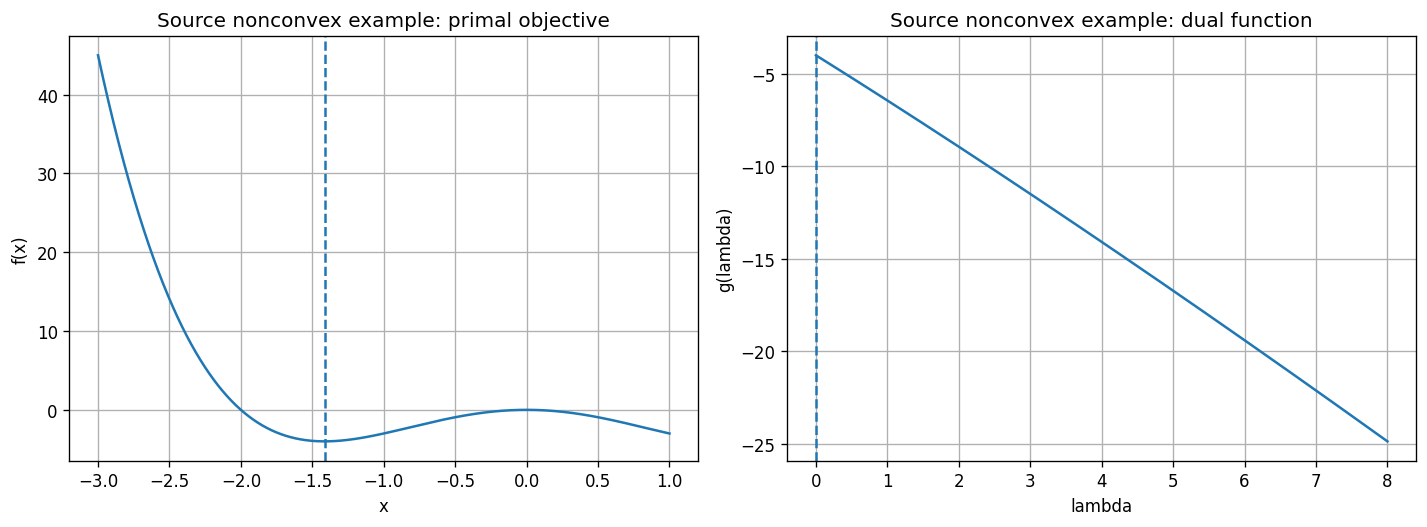

In [3]:
def quartic_primal(x):
    return x**4 - 4 * x**2

def quartic_dual_value(lam, x_grid):
    lagrangian_values = quartic_primal(x_grid) + lam * (x_grid - 1.0)
    idx = np.argmin(lagrangian_values)
    return lagrangian_values[idx], x_grid[idx]

x_feasible = np.linspace(-3.0, 1.0, 4001)
primal_values = quartic_primal(x_feasible)
primal_star = primal_values.min()
x_primal_star = x_feasible[np.argmin(primal_values)]

x_grid_dual = np.linspace(-3.0, 3.0, 6001)
lambda_grid = np.linspace(0.0, 8.0, 1601)
dual_values = np.array([quartic_dual_value(lam, x_grid_dual)[0] for lam in lambda_grid])
dual_star = dual_values.max()
lambda_star = lambda_grid[np.argmax(dual_values)]

print(f"Primal optimum (numerical): p* = {primal_star:.6f} at x = {x_primal_star:.4f}")
print(f"Dual optimum   (numerical): d* = {dual_star:.6f} at lambda = {lambda_star:.4f}")
print(f"Estimated gap: {primal_star - dual_star:.3e}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(x_feasible, primal_values, label="Primal objective")
axes[0].axvline(x_primal_star, linestyle="--")
axes[0].set_title("Source nonconvex example: primal objective")
axes[0].set_xlabel("x")
axes[0].set_ylabel("f(x)")
axes[0].grid(True)

axes[1].plot(lambda_grid, dual_values, label="Dual objective")
axes[1].axvline(lambda_star, linestyle="--")
axes[1].set_title("Source nonconvex example: dual function")
axes[1].set_xlabel("lambda")
axes[1].set_ylabel("g(lambda)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

위 계산은 노트북을 읽을 때 꼭 짚고 넘어가야 하는 포인트입니다.

### 관찰
이 예제는 **nonconvex primal**이지만, 수치적으로 보면
$p^\star \approx d^\star$

즉, **gap이 거의 0**입니다.

### 왜 중요한가?
학생들이 흔히 다음처럼 오해합니다.

> “convex면 gap이 0이고, nonconvex면 gap이 양수다.”

하지만 실제로는 그렇지 않습니다.

- convex이면 strong duality가 성립할 **가능성이 매우 높아지고**,  
- nonconvex이면 strong duality가 **보장되지 않을 뿐**, 우연히 또는 구조적으로 gap이 0일 수도 있습니다.

즉, **nonconvexity는 strong duality failure의 충분조건도 필요조건도 아닙니다.**

Nonconvex box example
Primal problem: minimize -x^2 subject to -1 <= x <= 1
Primal optimum: p* = -1 at x = -1 or x = 1
Dual optimum: d* = -inf


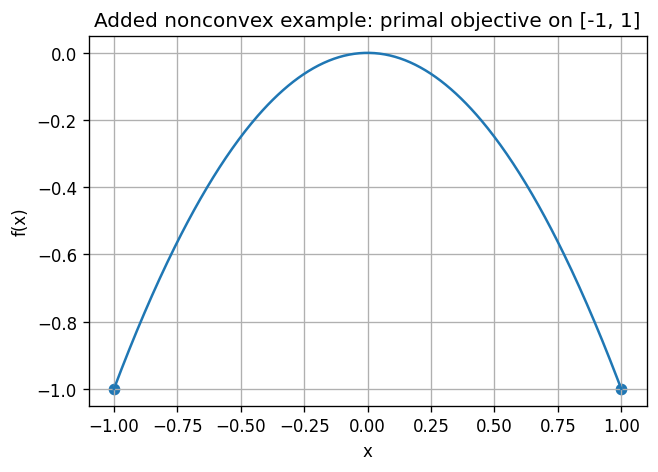

In [4]:
x_box = np.linspace(-1.0, 1.0, 400)
box_objective = -x_box**2

print("Nonconvex box example")
print("Primal problem: minimize -x^2 subject to -1 <= x <= 1")
print("Primal optimum: p* = -1 at x = -1 or x = 1")
print("Dual optimum: d* = -inf")

plt.figure(figsize=(6, 4))
plt.plot(x_box, box_objective)
plt.scatter([-1, 1], [-1, -1])
plt.title("Added nonconvex example: primal objective on [-1, 1]")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.show()

위 추가 예제에서는 strong duality가 아주 극적으로 깨집니다.

문제는
$\min_x \; -x^2 \qquad \text{subject to } -1\le x\le 1$
입니다.

이를 두 개의 선형 부등식
$x-1\le 0,\qquad -x-1\le 0$
로 쓰면, Lagrangian은
$L(x,\lambda_+,\lambda_-) = -x^2 + \lambda_+(x-1) + \lambda_-(-x-1)$
가 됩니다.

그런데 $-x^2$의 곡률은 끝까지 **음수**이므로, 어떤 \(\lambda_+,\lambda_-\ge 0\)를 골라도
$
\inf_x L(x,\lambda_+,\lambda_-) = -\infty
$
입니다. 따라서
$
d^\star = -\infty
$
가 되어 dual bound가 전혀 유용하지 않습니다.

### 여기서 얻는 교훈
nonconvex 문제에서는 dual function이 존재하더라도,  
그것이 **날카로운 lower bound**가 되리라는 보장이 없습니다.

Primal optimum (analytic/numerical): p* = 1.000000 at x = 1.0000
Dual optimum   (analytic/numerical): d* = 0.999994 at lambda = 1.9950
Estimated gap: 6.281e-06
CVXPY primal optimum: 1.000000
CVXPY dual variable for x >= 1: 2.000000
Solver used: CLARABEL


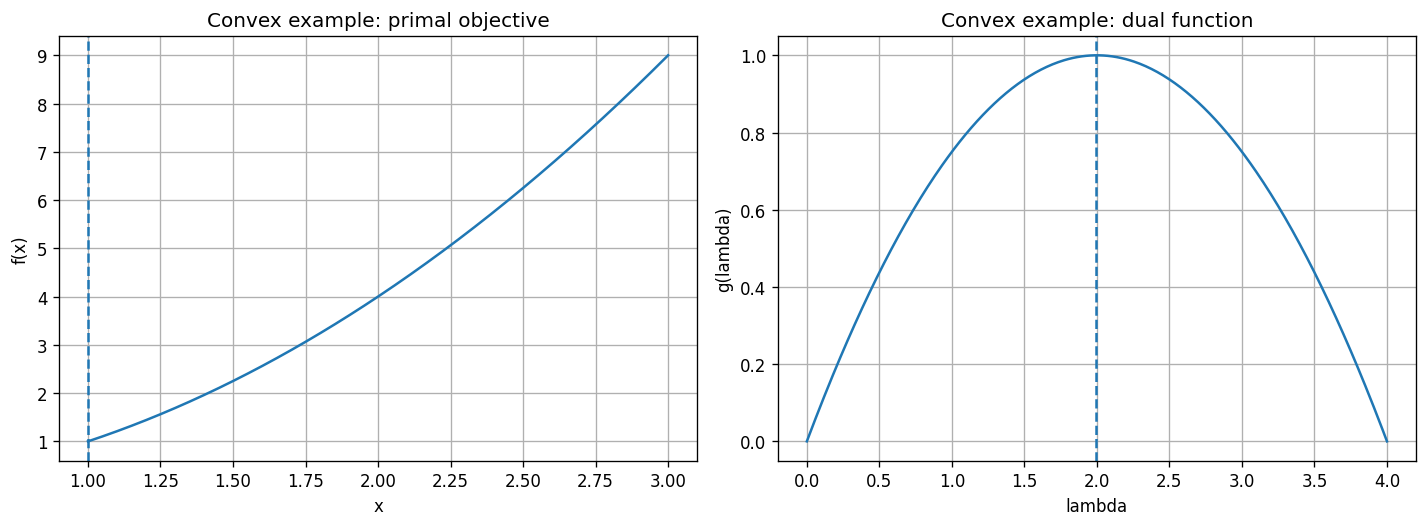

In [5]:
def convex_primal(x):
    return x**2

def convex_dual(lam):
    return lam - 0.25 * lam**2

x_convex = np.linspace(1.0, 3.0, 400)
lambda_convex = np.linspace(0.0, 4.0, 400)

primal_values_convex = convex_primal(x_convex)
dual_values_convex = convex_dual(lambda_convex)

primal_star_convex = primal_values_convex.min()
x_primal_star_convex = x_convex[np.argmin(primal_values_convex)]

dual_star_convex = dual_values_convex.max()
lambda_star_convex = lambda_convex[np.argmax(dual_values_convex)]

x_var = cp.Variable()
constraint = [x_var >= 1]
problem = cp.Problem(cp.Minimize(cp.square(x_var)), constraint)
benchmark_value, benchmark_solver = solve_problem(problem)

print(f"Primal optimum (analytic/numerical): p* = {primal_star_convex:.6f} at x = {x_primal_star_convex:.4f}")
print(f"Dual optimum   (analytic/numerical): d* = {dual_star_convex:.6f} at lambda = {lambda_star_convex:.4f}")
print(f"Estimated gap: {primal_star_convex - dual_star_convex:.3e}")
print(f"CVXPY primal optimum: {benchmark_value:.6f}")
print(f"CVXPY dual variable for x >= 1: {constraint[0].dual_value:.6f}")
print(f"Solver used: {benchmark_solver}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(x_convex, primal_values_convex)
axes[0].axvline(x_primal_star_convex, linestyle="--")
axes[0].set_title("Convex example: primal objective")
axes[0].set_xlabel("x")
axes[0].set_ylabel("f(x)")
axes[0].grid(True)

axes[1].plot(lambda_convex, dual_values_convex)
axes[1].axvline(lambda_star_convex, linestyle="--")
axes[1].set_title("Convex example: dual function")
axes[1].set_xlabel("lambda")
axes[1].set_ylabel("g(lambda)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [6]:
duality_examples = pd.DataFrame(
    [
        {
            "example": "Source quartic nonconvex",
            "primal_optimum": float(primal_star),
            "dual_optimum": float(dual_star),
            "gap": float(primal_star - dual_star),
            "message": "Nonconvex, but the gap is nearly zero."
        },
        {
            "example": "Added concave quadratic on box",
            "primal_optimum": -1.0,
            "dual_optimum": -np.inf,
            "gap": np.inf,
            "message": "Strong duality fails dramatically."
        },
        {
            "example": "Convex quadratic with Slater",
            "primal_optimum": float(primal_star_convex),
            "dual_optimum": float(dual_star_convex),
            "gap": float(primal_star_convex - dual_star_convex),
            "message": "Strong duality holds."
        },
    ]
)
display(duality_examples)

,example,primal_optimum,dual_optimum,gap,message
0,Source quartic nonconvex,-4.0,-4.000000,0.000000,"Nonconvex, but the gap is nearly zero."
1,Added concave quadratic on box,-1.0,-inf,inf,Strong duality fails dramatically.
2,Convex quadratic with Slater,1.0,0.999994,0.000006,Strong duality holds.


### Part 1 정리

지금까지 세 가지 상황을 보았습니다.

1. **nonconvex인데 gap이 거의 0인 경우**
2. **nonconvex라서 dual bound가 완전히 무너지는 경우**
3. **convex + Slater라서 gap이 0인 경우**

이제 중요한 연결고리가 생깁니다.

- strong duality가 성립하면 dual variable은 단순한 보조변수가 아니라  
  **최적성 조건(KKT)을 구성하는 실제 해석 도구**가 됩니다.
- 그리고 KKT system을 선형화하면 곧바로 **Newton step**이 등장합니다.

그래서 다음 Part에서는 equality constraint가 있는 문제에서 Newton method를 **직접 구현**해 보겠습니다.

## Part 2. Equality-constrained analytic centering과 Newton 방법

$
\min_x \; -\sum_{i=1}^n \log x_i
\qquad \text{subject to}\qquad
Ax=b,\quad x>0
$

이 문제는 두 가지 이유로 중요합니다.

1. **수학적으로**: log barrier의 가장 전형적인 형태입니다.  
2. **알고리즘적으로**: interior-point method에서 반복적으로 풀게 되는 중심화(centering) subproblem의 원형입니다.

### 부호를 정확히 보자
이 문제는 다음과 동치입니다.
$
\max_x \; \sum_{i=1}^n \log x_i
\qquad \text{subject to}\qquad
Ax=b,\quad x>0
$

즉,
- **maximize \(\sum \log x_i\)** 로 읽어도 되고,
- **minimize \(-\sum \log x_i\)** 로 읽어도 됩니다.

이 노트북에서는 원본 코드와 맞추기 위해 **minimize $-\sum \log x_i$** 형태로 통일하겠습니다.

### gradient, Hessian, KKT system

목적함수
$
f(x) = -\sum_{i=1}^n \log x_i
$
에 대해

$
\nabla f(x) = \left(-\frac{1}{x_1},\dots,-\frac{1}{x_n}\right),\qquad
\nabla^2 f(x)=\mathrm{diag}\left(\frac{1}{x_1^2},\dots,\frac{1}{x_n^2}\right)
$

입니다.

Equality-constrained Newton step $(\Delta x, w)$는 다음 선형계로 구합니다.

$
\begin{bmatrix}
\nabla^2 f(x) & A^\top \\
A & 0
\end{bmatrix}
\begin{bmatrix}
\Delta x \\
w
\end{bmatrix}
=
-
\begin{bmatrix}
\nabla f(x) \\
0
\end{bmatrix}
$

여기서 중요한 점은, feasible point에서 시작하면 \(A\Delta x=0\)이므로
Newton update가 affine constraint를 계속 유지한다는 것입니다.

또한 Newton decrement
$
\lambda(x)^2 = -\nabla f(x)^\top \Delta x
$
는 “지금 점이 얼마나 최적점에 가까운가”를 측정하는 매우 중요한 지표입니다.

In [7]:
def generate_analytic_center_instance(m=6, n=40, seed=3):
    local_rng = np.random.default_rng(seed)

    while True:
        A = 0.1 + local_rng.random((m, n))
        A[0, :] = 1.0
        if np.linalg.matrix_rank(A) == m:
            break

    x_reference = local_rng.random(n)
    x_reference = x_reference / x_reference.sum()
    b = A @ x_reference
    return A, b, x_reference

def analytic_center_objective(x):
    return -np.sum(np.log(x))

def analytic_center_gradient(x):
    return -1.0 / x

def analytic_center_hessian(x):
    return np.diag(1.0 / x**2)

def solve_analytic_center_cvxpy(A, b):
    n = A.shape[1]
    x = cp.Variable(n, pos=True)
    problem = cp.Problem(cp.Minimize(cp.sum(-cp.log(x))), [A @ x == b])
    value, solver = solve_problem(problem)
    return x.value, value, solver

A, b, x_reference = generate_analytic_center_instance(m=6, n=40, seed=4)
x_benchmark, value_benchmark, solver_benchmark = solve_analytic_center_cvxpy(A, b)

instance_summary = pd.DataFrame(
    [
        {
            "rows_m": A.shape[0],
            "cols_n": A.shape[1],
            "rank(A)": np.linalg.matrix_rank(A),
            "benchmark_value": value_benchmark,
            "solver": solver_benchmark,
            "sum(x_benchmark)": x_benchmark.sum(),
            "min(x_benchmark)": x_benchmark.min(),
        }
    ]
)
display(instance_summary)

,rows_m,cols_n,rank(A),benchmark_value,solver,sum(x_benchmark),min(x_benchmark)
0,6,40,6,147.855378,CLARABEL,1.0,0.019305


In [8]:
def initialize_feasible_primal(A, b, epsilon=1e-4):
    n = A.shape[1]
    x = cp.Variable(n)
    problem = cp.Problem(cp.Minimize(0), [A @ x == b, x >= epsilon])
    solve_problem(problem)
    return x.value

def check_primal_feasibility(A, b, x):
    return {
        "eq_residual_norm": float(np.linalg.norm(A @ x - b)),
        "min_entry": float(np.min(x)),
        "is_positive": bool(np.all(x > 0)),
    }

x0_feasible = initialize_feasible_primal(A, b)
display(pd.DataFrame([check_primal_feasibility(A, b, x0_feasible)]))

,eq_residual_norm,min_entry,is_positive
0,3.161700e-15,0.020834,True


In [9]:
def equality_constrained_newton(A, b, x0, tol=1e-10, max_iter=50, alpha=0.1, beta=0.5):
    m, n = A.shape
    x = x0.copy().astype(float)

    history_rows = []

    for iteration in range(max_iter):
        grad = analytic_center_gradient(x)
        hess = analytic_center_hessian(x)

        kkt_matrix = np.block(
            [
                [hess, A.T],
                [A, np.zeros((m, m))],
            ]
        )
        rhs = np.concatenate([-grad, np.zeros(m)])
        solution = np.linalg.solve(kkt_matrix, rhs)

        dx = solution[:n]
        decrement_sq = -grad @ dx

        history_rows.append(
            {
                "iter": iteration,
                "objective": analytic_center_objective(x),
                "newton_decrement": math.sqrt(max(decrement_sq, 0.0)),
                "eq_residual_norm": np.linalg.norm(A @ x - b),
                "min_entry": np.min(x),
            }
        )

        if decrement_sq / 2 <= tol:
            break

        step = 1.0
        while np.min(x + step * dx) <= 0:
            step *= beta

        current_value = analytic_center_objective(x)
        directional_derivative = grad @ dx

        while analytic_center_objective(x + step * dx) > current_value + alpha * step * directional_derivative:
            step *= beta
            if step < 1e-16:
                break

        x = x + step * dx
        history_rows[-1]["step_size"] = step

    history = pd.DataFrame(history_rows)
    return x, history

Benchmark objective: 147.8553778351
Newton objective   : 147.8553763996
Distance to benchmark solution: 1.961e-05


,iter,objective,newton_decrement,eq_residual_norm,min_entry,step_size
0,0,147.894487,2.864079e-01,3.161700e-15,0.020834,1.0
1,1,147.855759,2.752927e-02,3.211981e-15,0.019117,1.0
2,2,147.855376,4.059528e-04,2.880168e-15,0.019298,1.0
3,3,147.855376,4.422545e-08,2.388915e-15,0.019301,NaN


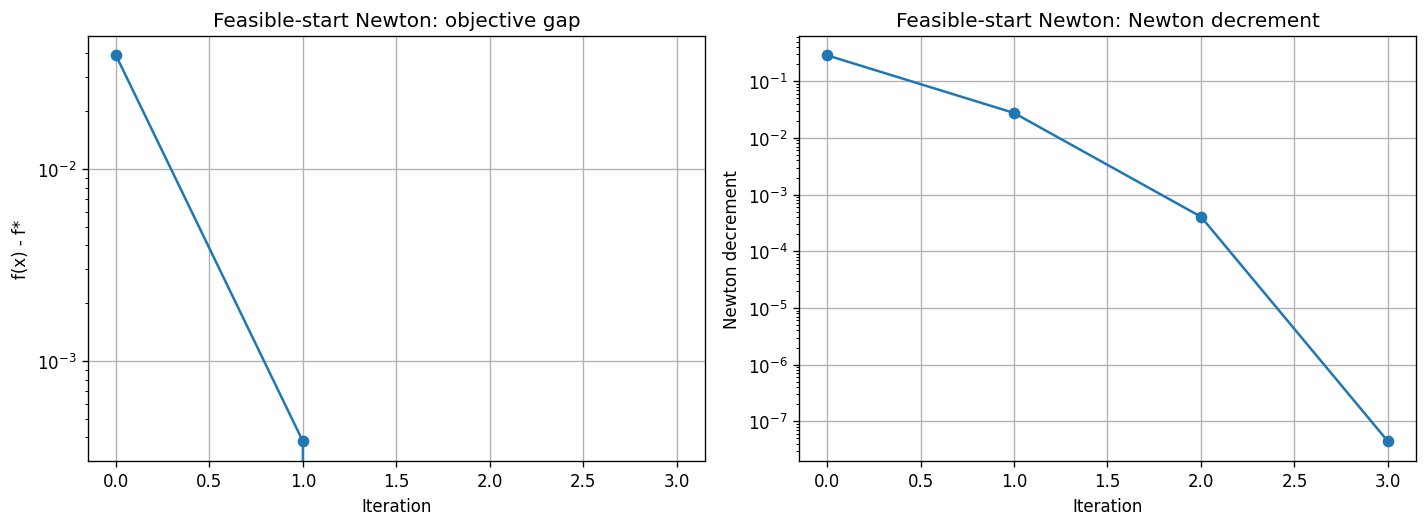

In [10]:
x_eq_newton, history_eq_newton = equality_constrained_newton(A, b, x0_feasible)

print(f"Benchmark objective: {value_benchmark:.10f}")
print(f"Newton objective   : {analytic_center_objective(x_eq_newton):.10f}")
print(f"Distance to benchmark solution: {np.linalg.norm(x_eq_newton - x_benchmark):.3e}")

display(history_eq_newton)

objective_gap_eq = history_eq_newton["objective"].values - value_benchmark
decrement_eq = history_eq_newton["newton_decrement"].values

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(range(len(objective_gap_eq)), objective_gap_eq, marker="o")
axes[0].set_title("Feasible-start Newton: objective gap")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("f(x) - f*")
axes[0].set_yscale("log")
axes[0].grid(True)

axes[1].plot(range(len(decrement_eq)), decrement_eq, marker="o")
axes[1].set_title("Feasible-start Newton: Newton decrement")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Newton decrement")
axes[1].set_yscale("log")
axes[1].grid(True)

plt.tight_layout()
plt.show()

### 왜 이 그림이 중요한가?

왼쪽의 objective gap이 빠르게 줄고, 오른쪽의 Newton decrement도 급격히 줄어듭니다.  
이것이 바로 Newton method가 최적점 근처에서 강력한 이유입니다.

### 해석 포인트
- feasible-start Newton은 **constraint를 처음부터 끝까지 정확히 유지**합니다.
- 따라서 관심사는 “feasibility 복구”가 아니라 **stationarity를 얼마나 빨리 맞추느냐**입니다.
- Hessian이 잘 behaved한 영역에 들어가면, Newton은 보통 **매우 빠른 수렴**을 보입니다.

하지만 실전에서는 항상 feasible point를 손쉽게 만들 수 있는 것이 아닙니다.  
그래서 다음으로는 **infeasible-start Newton**을 봅니다.

### Infeasible-start Newton method

이제는 시작점이 $Ax=b$를 만족하지 않아도 된다고 가정합니다.  
그러면 더 이상 $A\Delta x=0$만으로는 충분하지 않고, **primal residual**까지 같이 줄여야 합니다.

Residual을 다음처럼 둡니다.

$
r(x,\nu)=
\begin{bmatrix}
\nabla f(x) + A^\top \nu \\
Ax-b
\end{bmatrix}
$

그러면 Newton step $(\Delta x, \Delta \nu)$는

$
\begin{bmatrix}
\nabla^2 f(x) & A^\top \\
A & 0
\end{bmatrix}
\begin{bmatrix}
\Delta x \\
\Delta \nu
\end{bmatrix}
=
-
\begin{bmatrix}
\nabla f(x)+A^\top \nu \\
Ax-b
\end{bmatrix}
$

를 풀어 얻습니다.

즉, feasible-start Newton이 “stationarity만 맞추는 Newton”이라면,  
infeasible-start Newton은 “stationarity와 feasibility를 동시에 맞추는 Newton”입니다.

In [11]:
def infeasible_newton(A, b, x0, nu0=None, tol=1e-9, max_iter=80, alpha=0.15, beta=0.6):
    m, n = A.shape
    x = x0.copy().astype(float)
    nu = np.zeros(m) if nu0 is None else nu0.copy().astype(float)

    history_rows = []

    def residual(x, nu):
        return np.concatenate([analytic_center_gradient(x) + A.T @ nu, A @ x - b])

    for iteration in range(max_iter):
        grad = analytic_center_gradient(x)
        hess = analytic_center_hessian(x)
        residual_value = residual(x, nu)
        residual_norm = np.linalg.norm(residual_value)

        history_rows.append(
            {
                "iter": iteration,
                "objective": analytic_center_objective(x),
                "residual_norm": residual_norm,
                "eq_residual_norm": np.linalg.norm(A @ x - b),
                "min_entry": np.min(x),
            }
        )

        if residual_norm <= tol:
            break

        kkt_matrix = np.block(
            [
                [hess, A.T],
                [A, np.zeros((m, m))],
            ]
        )
        solution = np.linalg.solve(kkt_matrix, -residual_value)

        dx = solution[:n]
        dnu = solution[n:]

        step = 1.0
        while np.min(x + step * dx) <= 0:
            step *= beta

        while np.linalg.norm(residual(x + step * dx, nu + step * dnu)) > (1 - alpha * step) * residual_norm:
            step *= beta
            if step < 1e-16:
                break

        x = x + step * dx
        nu = nu + step * dnu
        history_rows[-1]["step_size"] = step

    history = pd.DataFrame(history_rows)
    return x, nu, history

Benchmark objective: 147.8553778351
Infeasible Newton objective: 147.8553763996
Distance to benchmark solution: 1.961e-05


,iter,objective,residual_norm,eq_residual_norm,min_entry,step_size
0,0,156.480920,3.162280e+02,3.752706e-01,0.020000,1.0
1,1,147.864326,2.566877e+01,1.047382e-15,0.017962,1.0
2,2,147.855391,2.872919e-01,3.510833e-16,0.019221,1.0
3,3,147.855376,8.994815e-04,1.570092e-16,0.019301,1.0
4,4,147.855376,1.059632e-08,0.000000e+00,0.019301,1.0
5,5,147.855376,4.792976e-14,3.140185e-16,0.019301,NaN


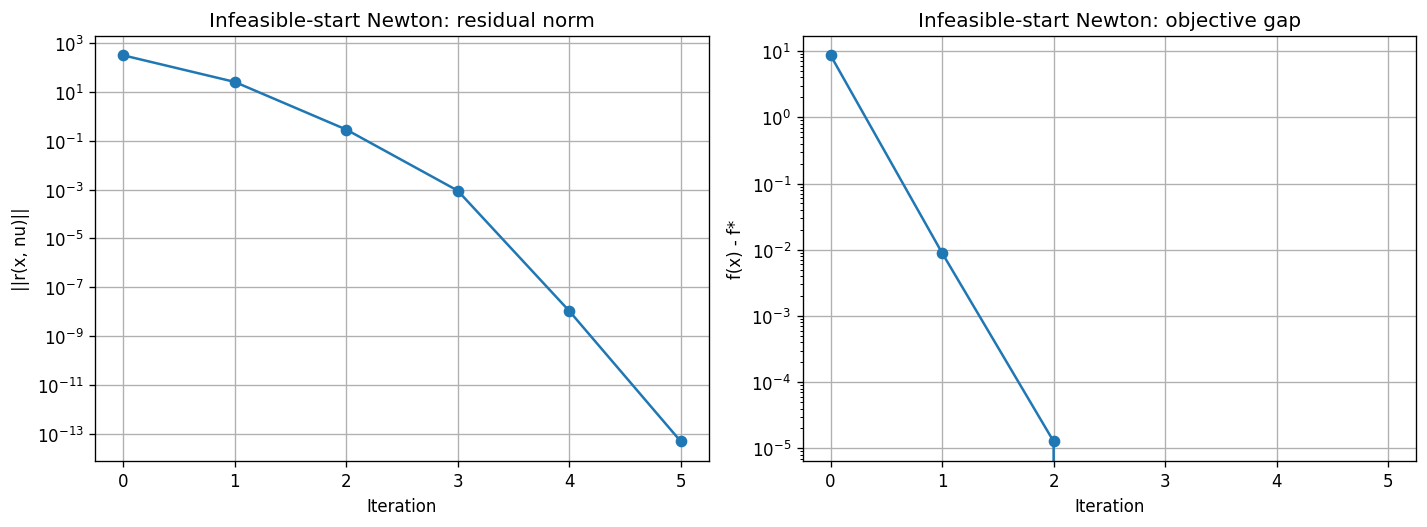

In [12]:
x0_infeasible = 0.8 * np.full(A.shape[1], 1.0 / A.shape[1])
nu0_infeasible = np.zeros(A.shape[0])

x_infeasible_newton, nu_infeasible_newton, history_infeasible = infeasible_newton(
    A, b, x0_infeasible, nu0_infeasible
)

print(f"Benchmark objective: {value_benchmark:.10f}")
print(f"Infeasible Newton objective: {analytic_center_objective(x_infeasible_newton):.10f}")
print(f"Distance to benchmark solution: {np.linalg.norm(x_infeasible_newton - x_benchmark):.3e}")

display(history_infeasible)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(history_infeasible["iter"], history_infeasible["residual_norm"], marker="o")
axes[0].set_title("Infeasible-start Newton: residual norm")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("||r(x, nu)||")
axes[0].set_yscale("log")
axes[0].grid(True)

axes[1].plot(
    history_infeasible["iter"],
    history_infeasible["objective"] - value_benchmark,
    marker="o"
)
axes[1].set_title("Infeasible-start Newton: objective gap")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("f(x) - f*")
axes[1].set_yscale("log")
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Dual Newton method

이제 같은 문제를 dual 쪽에서 보겠습니다.

Primal:
$
\min_x\; -\sum_{i=1}^n \log x_i
\quad \text{subject to}\quad
Ax=b,\; x>0
$

Lagrangian:
$
L(x,\nu)= -\sum_i \log x_i + \nu^\top (Ax-b)
$

$x$에 대해 미분하면
$
-\frac{1}{x_i} + (A^\top \nu)_i = 0
\quad\Longrightarrow\quad
x_i = \frac{1}{(A^\top \nu)_i}
$
가 됩니다. 따라서 \(A^\top \nu > 0\)일 때 dual function은

$
g(\nu) = -b^\top \nu + \sum_{i=1}^n \log (A^\top \nu)_i + n
$

이 됩니다.

여기서 중요한 점은, dual optimum \(\nu^\star\)를 구하면 primal solution을
$
x^\star = \frac{1}{A^\top \nu^\star}
$
형태로 **복원**할 수 있다는 것입니다.

In [13]:
def dual_objective_analytic_center(A, b, nu):
    y = A.T @ nu
    if np.any(y <= 0):
        return -np.inf
    return -b @ nu + np.sum(np.log(y)) + len(y)

def dual_gradient_analytic_center(A, b, nu):
    y = A.T @ nu
    return -b + A @ (1.0 / y)

def dual_hessian_analytic_center(A, nu):
    y = A.T @ nu
    return -A @ np.diag(1.0 / y**2) @ A.T

def initialize_feasible_dual(A, epsilon=1e-3):
    m = A.shape[0]
    nu = cp.Variable(m)
    problem = cp.Problem(cp.Minimize(0), [A.T @ nu >= epsilon])
    solve_problem(problem)
    return nu.value

def dual_newton(A, b, nu0, tol=1e-10, max_iter=60, alpha=0.1, beta=0.5):
    nu = nu0.copy().astype(float)
    history_rows = []

    for iteration in range(max_iter):
        grad = dual_gradient_analytic_center(A, b, nu)
        hess = dual_hessian_analytic_center(A, nu)
        grad_norm = np.linalg.norm(grad)
        value = dual_objective_analytic_center(A, b, nu)

        history_rows.append(
            {
                "iter": iteration,
                "dual_objective": value,
                "grad_norm": grad_norm,
                "min_At_nu": np.min(A.T @ nu),
            }
        )

        if grad_norm <= tol:
            break

        dnu = np.linalg.solve(hess, -grad)

        step = 1.0
        while np.min(A.T @ (nu + step * dnu)) <= 0:
            step *= beta

        directional_derivative = grad @ dnu
        while dual_objective_analytic_center(A, b, nu + step * dnu) < value + alpha * step * directional_derivative:
            step *= beta
            if step < 1e-16:
                break

        nu = nu + step * dnu
        history_rows[-1]["step_size"] = step

    x_recovered = 1.0 / (A.T @ nu)
    history = pd.DataFrame(history_rows)
    return nu, x_recovered, history

Benchmark primal value: 147.8553778351
Recovered primal value from dual Newton: 147.8553763977
Final dual value: 147.8553763996
Primal-dual gap: -1.869e-09
Distance to benchmark solution: 1.961e-05


,iter,dual_objective,grad_norm,min_At_nu,step_size
0,0,39.280523,6.813339e+01,0.995770,1.0
1,1,65.517476,3.362668e+01,1.973865,1.0
2,2,90.346797,1.637918e+01,3.856675,1.0
3,3,112.587086,7.767107e+00,7.263351,1.0
4,4,130.443606,3.484321e+00,12.845637,1.0
5,5,141.989707,1.388518e+00,20.390789,1.0
6,6,146.883323,4.250304e-01,27.255222,1.0
7,7,147.814650,7.080837e-02,29.981877,1.0
8,8,147.855270,3.035227e-03,30.026086,1.0
9,9,147.855376,7.866730e-06,29.994624,1.0


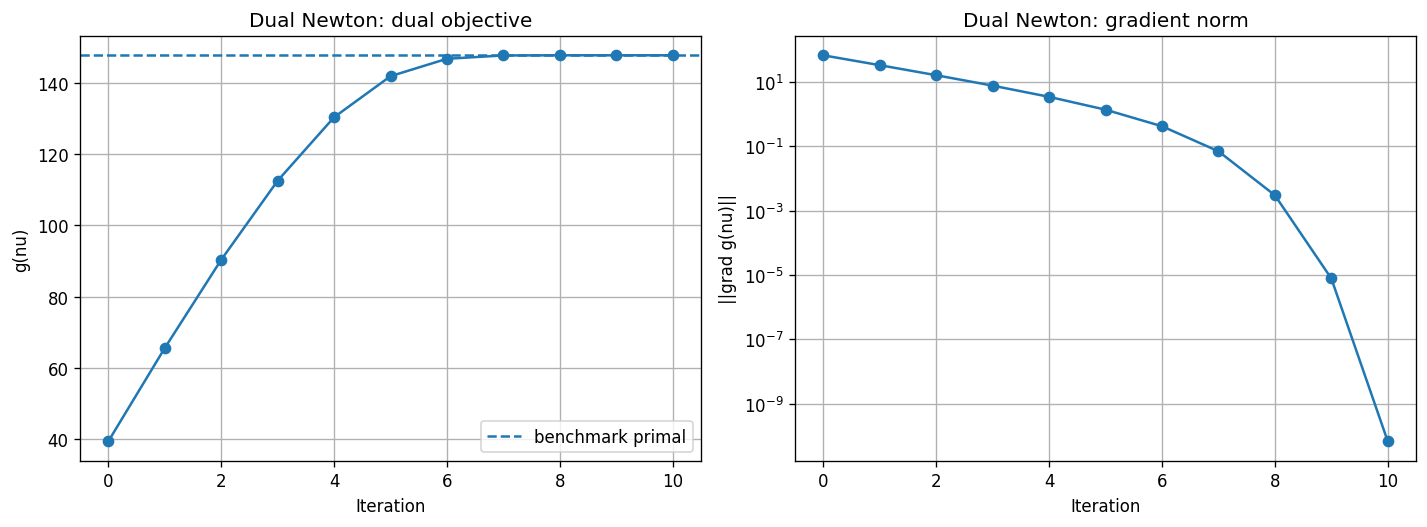

In [14]:
nu0_dual = initialize_feasible_dual(A)
nu_dual, x_dual_recovered, history_dual = dual_newton(A, b, nu0_dual)

primal_value_from_dual = analytic_center_objective(x_dual_recovered)
dual_value_final = dual_objective_analytic_center(A, b, nu_dual)

print(f"Benchmark primal value: {value_benchmark:.10f}")
print(f"Recovered primal value from dual Newton: {primal_value_from_dual:.10f}")
print(f"Final dual value: {dual_value_final:.10f}")
print(f"Primal-dual gap: {primal_value_from_dual - dual_value_final:.3e}")
print(f"Distance to benchmark solution: {np.linalg.norm(x_dual_recovered - x_benchmark):.3e}")

display(history_dual)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(history_dual["iter"], history_dual["dual_objective"], marker="o")
axes[0].axhline(value_benchmark, linestyle="--", label="benchmark primal")
axes[0].set_title("Dual Newton: dual objective")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("g(nu)")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(history_dual["iter"], history_dual["grad_norm"], marker="o")
axes[1].set_title("Dual Newton: gradient norm")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("||grad g(nu)||")
axes[1].set_yscale("log")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [15]:
comparison_part2 = pd.DataFrame(
    [
        {
            "method": "CVXPY benchmark",
            "objective": value_benchmark,
            "eq_residual_norm": np.linalg.norm(A @ x_benchmark - b),
            "min_entry": np.min(x_benchmark),
            "distance_to_benchmark": 0.0,
            "iterations": np.nan,
        },
        {
            "method": "Feasible-start Newton",
            "objective": analytic_center_objective(x_eq_newton),
            "eq_residual_norm": np.linalg.norm(A @ x_eq_newton - b),
            "min_entry": np.min(x_eq_newton),
            "distance_to_benchmark": np.linalg.norm(x_eq_newton - x_benchmark),
            "iterations": len(history_eq_newton),
        },
        {
            "method": "Infeasible-start Newton",
            "objective": analytic_center_objective(x_infeasible_newton),
            "eq_residual_norm": np.linalg.norm(A @ x_infeasible_newton - b),
            "min_entry": np.min(x_infeasible_newton),
            "distance_to_benchmark": np.linalg.norm(x_infeasible_newton - x_benchmark),
            "iterations": len(history_infeasible),
        },
        {
            "method": "Dual Newton + primal recovery",
            "objective": analytic_center_objective(x_dual_recovered),
            "eq_residual_norm": np.linalg.norm(A @ x_dual_recovered - b),
            "min_entry": np.min(x_dual_recovered),
            "distance_to_benchmark": np.linalg.norm(x_dual_recovered - x_benchmark),
            "iterations": len(history_dual),
        },
    ]
)
display(comparison_part2)

,method,objective,eq_residual_norm,min_entry,distance_to_benchmark,iterations
0,CVXPY benchmark,147.855378,5.105073e-08,0.019305,0.00000,NaN
1,Feasible-start Newton,147.855376,2.388915e-15,0.019301,0.00002,4.0
2,Infeasible-start Newton,147.855376,3.140185e-16,0.019301,0.00002,6.0
3,Dual Newton + primal recovery,147.855376,6.788505e-11,0.019301,0.00002,11.0


## Part 3. Barrier function과 central path

이제 equality constraint만 있는 Newton 문제에서, 다시 inequality constraint가 있는 문제로 돌아갑니다.

핵심 아이디어는 매우 단순합니다.

$
h_i(x)\le 0
$
를 직접 다루는 대신,
$
-\log(-h_i(x))
$
를 objective에 더해 boundary를 넘지 못하게 만듭니다.

### log barrier
$
\phi(x) = -\sum_{i=1}^m \log(-h_i(x))
$

그리고 barrier subproblem은
$
\min_x \; t f(x) + \phi(x)
$
형태가 됩니다.

여기서 $t$가 커질수록 원래 objective $f(x)$가 더 중요해지고,  
$t$가 작을수록 barrier가 더 중요해집니다.

또한 central path 상에서는
$
\text{surrogate gap} \approx \frac{m}{t}
$
라는 매우 중요한 stopping proxy가 나옵니다.

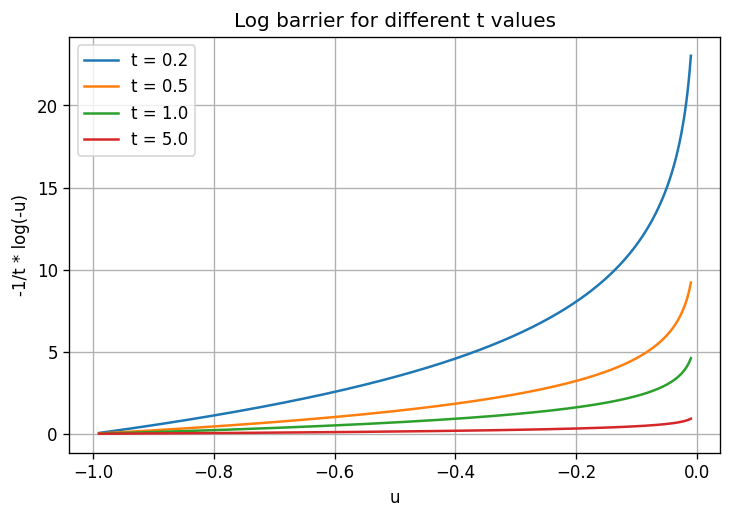

In [16]:
def log_barrier(u, t):
    return -(1.0 / t) * np.log(-u)

u_values = np.linspace(-0.99, -0.01, 500)
t_values_barrier = [0.2, 0.5, 1.0, 5.0]

plt.figure(figsize=(7, 4.5))
for t in t_values_barrier:
    plt.plot(u_values, log_barrier(u_values, t), label=f"t = {t}")

plt.title("Log barrier for different t values")
plt.xlabel("u")
plt.ylabel("-1/t * log(-u)")
plt.grid(True)
plt.legend()
plt.show()

### 1차원에서 central path를 먼저 보자

여기서는 barrier의 효과가 더 잘 보이도록, 약간 더 학습가능한 파라미터로 선택하겠습니다.

문제는
$
\min_x \; (x-1.4)^2
\qquad \text{subject to}\qquad
x^2 \le 1
$
입니다.

원래 constrained optimum은 $x^\star = 1$로 **boundary 위**에 있습니다.  
따라서 $t$를 키우면 barrier minimizer $x_t$가 내부에서 boundary 쪽으로 다가가는 모습이 분명하게 드러납니다.

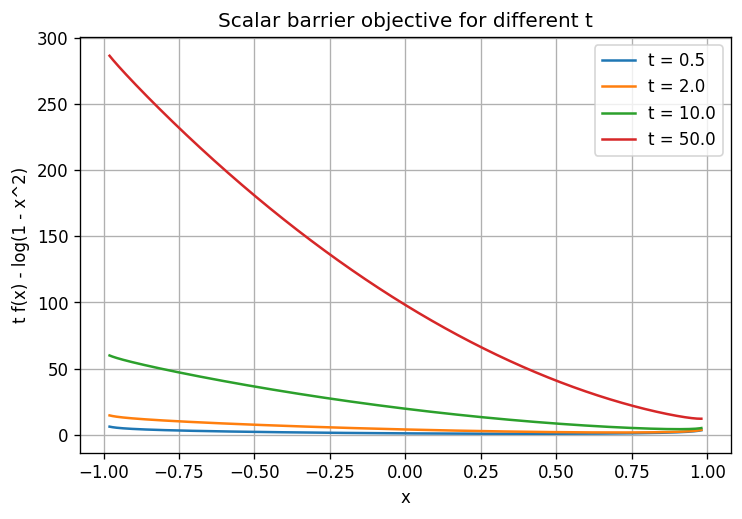

,t,x_t,barrier_objective_min
0,0.5,0.410968,0.674091
1,2.0,0.703571,1.653248
2,10.0,0.904031,4.159609
3,50.0,0.976569,12.037023


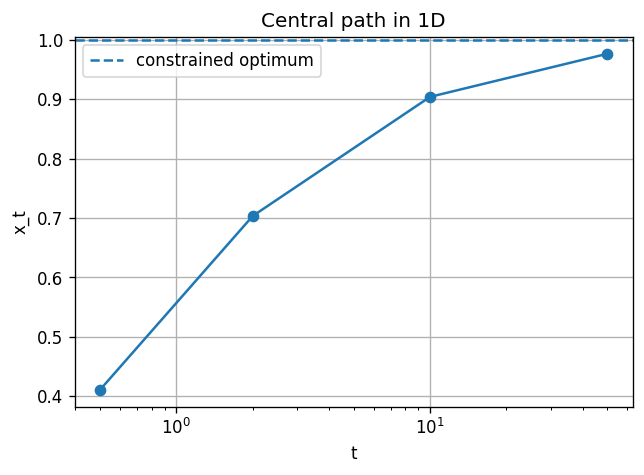

In [17]:
def scalar_objective(x):
    return (x - 1.4) ** 2

def scalar_barrier_objective(x, t):
    values = t * (x - 1.4) ** 2 - np.log(1 - x**2)
    return values

x_line = np.linspace(-0.98, 0.98, 4000)
t_values_scalar = [0.5, 2.0, 10.0, 50.0]

central_path_rows = []
plt.figure(figsize=(7, 4.5))
for t in t_values_scalar:
    barrier_values = scalar_barrier_objective(x_line, t)
    x_t = x_line[np.argmin(barrier_values)]
    central_path_rows.append({"t": t, "x_t": x_t, "barrier_objective_min": barrier_values.min()})
    plt.plot(x_line, barrier_values, label=f"t = {t}")

plt.title("Scalar barrier objective for different t")
plt.xlabel("x")
plt.ylabel("t f(x) - log(1 - x^2)")
plt.grid(True)
plt.legend()
plt.show()

central_path_df = pd.DataFrame(central_path_rows)
display(central_path_df)

plt.figure(figsize=(6, 4))
plt.plot(central_path_df["t"], central_path_df["x_t"], marker="o")
plt.axhline(1.0, linestyle="--", label="constrained optimum")
plt.xscale("log")
plt.title("Central path in 1D")
plt.xlabel("t")
plt.ylabel("x_t")
plt.grid(True)
plt.legend()
plt.show()

표에서 보듯이 \(t\)가 커질수록 \(x_t\)는 내부에서 \(1\)에 가까워집니다.  
이것이 barrier method의 핵심 직관입니다.

- 작은 $t$: **feasibility와 중앙성**을 더 중시  
- 큰 $t$: 원래 objective를 더 강하게 반영  
- 결국 $t\to\infty$: central path가 원래 constrained optimum으로 수렴  

이제 원본 노트북의 2차원 예제로 넘어가겠습니다.

### 2차원 convex example

예제

$
\min_{x_1,x_2}\; (x_1-5)^2 + (x_2-6)^2
$
subject to


\begin{aligned}
x_1^2 - 4 &\le 0,\\
e^{-x_1} - x_2 &\le 0,\\
x_1 + 2x_2 - 4 &\le 0,\\
x_1 &\ge 0,\\
x_2 &\ge 0.
\end{aligned}


이 문제는 convex입니다.

- objective는 quadratic convex
- $x_1^2-4\le 0$는 $|x_1|\le 2$
- $e^{-x_1}\le x_2$는 convex function의 epigraph
- 나머지는 linear inequality

따라서 이 문제는 barrier / primal-dual 방법을 시험하기에 아주 좋은 예제입니다.

In [18]:
def objective_2d(x):
    x = np.asarray(x)
    return (x[0] - 5.0) ** 2 + (x[1] - 6.0) ** 2

def gradient_objective_2d(x):
    x = np.asarray(x)
    return np.array([2 * (x[0] - 5.0), 2 * (x[1] - 6.0)])

def h_2d(x):
    x1, x2 = x
    return np.array(
        [
            x1**2 - 4.0,
            np.exp(-x1) - x2,
            x1 + 2 * x2 - 4.0,
            -x1,
            -x2,
        ]
    )

def jacobian_h_2d(x):
    x1, x2 = x
    return np.array(
        [
            [2 * x1, 0.0],
            [-np.exp(-x1), -1.0],
            [1.0, 2.0],
            [-1.0, 0.0],
            [0.0, -1.0],
        ]
    )

def hessian_h_2d_list(x):
    x1, _ = x
    return [
        np.array([[2.0, 0.0], [0.0, 0.0]]),
        np.array([[np.exp(-x1), 0.0], [0.0, 0.0]]),
        np.zeros((2, 2)),
        np.zeros((2, 2)),
        np.zeros((2, 2)),
    ]

x_var_2d = cp.Variable(2)
constraints_2d = [
    cp.square(x_var_2d[0]) <= 4,
    cp.exp(-x_var_2d[0]) <= x_var_2d[1],
    x_var_2d[0] + 2 * x_var_2d[1] <= 4,
    x_var_2d[0] >= 0,
    x_var_2d[1] >= 0,
]
problem_2d = cp.Problem(cp.Minimize(cp.sum_squares(x_var_2d - np.array([5.0, 6.0]))), constraints_2d)
value_2d_benchmark, solver_2d = solve_problem(problem_2d)

x_2d_benchmark = x_var_2d.value
dual_values_2d = [
    constraints_2d[0].dual_value,
    constraints_2d[1].dual_value,
    constraints_2d[2].dual_value,
    constraints_2d[3].dual_value,
    constraints_2d[4].dual_value,
]

print(f"Benchmark solution: x* = {x_2d_benchmark}")
print(f"Benchmark objective: {value_2d_benchmark:.8f}")
print(f"Solver used: {solver_2d}")

dual_table_2d = pd.DataFrame(
    {
        "constraint": [
            "x1^2 <= 4",
            "exp(-x1) <= x2",
            "x1 + 2 x2 <= 4",
            "x1 >= 0",
            "x2 >= 0",
        ],
        "dual_value": dual_values_2d,
    }
)
display(dual_table_2d)

Benchmark solution: x* = [2. 1.]
Benchmark objective: 34.00000000
Solver used: CLARABEL


,constraint,dual_value
0,x1^2 <= 4,2.500003e-01
1,exp(-x1) <= x2,1.790312e-09
2,x1 + 2 x2 <= 4,5.000000e+00
3,x1 >= 0,2.244175e-10
4,x2 >= 0,8.787999e-10


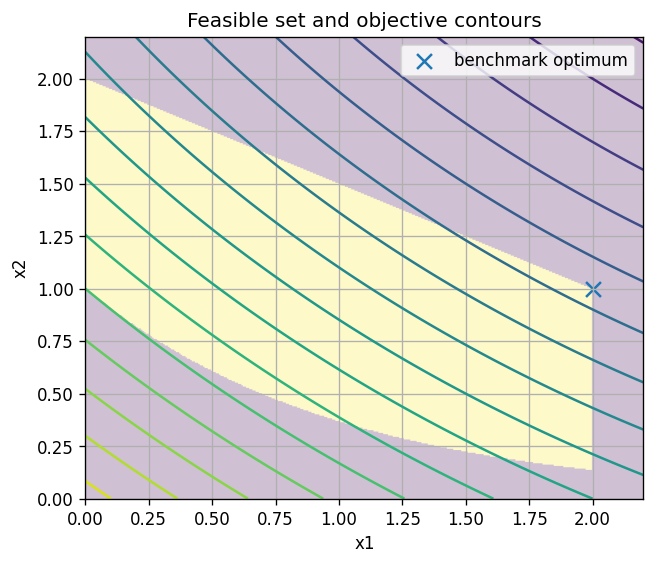

In [19]:
X, Y = make_grid((0.0, 2.2), (0.0, 2.2), n=350)

feasible_mask = (
    (X**2 - 4.0 <= 0)
    & (np.exp(-X) - Y <= 0)
    & (X + 2 * Y - 4.0 <= 0)
    & (X >= 0)
    & (Y >= 0)
)

Z = (X - 5.0) ** 2 + (Y - 6.0) ** 2

plt.figure(figsize=(6, 5))
plt.contour(X, Y, Z, levels=18)
plt.imshow(
    feasible_mask.astype(float),
    extent=(X.min(), X.max(), Y.min(), Y.max()),
    origin="lower",
    alpha=0.25,
    aspect="auto",
)
plt.scatter([x_2d_benchmark[0]], [x_2d_benchmark[1]], marker="x", s=80, label="benchmark optimum")
plt.title("Feasible set and objective contours")
plt.xlabel("x1")
plt.ylabel("x2")
plt.xlim(0, 2.2)
plt.ylim(0, 2.2)
plt.legend()
plt.grid(True)
plt.show()

이 그림을 보면 최적점이 왜 \((2,1)\) 근처에 있어야 하는지가 직관적으로 보입니다.

- 원래 objective는 \((5,6)\) 쪽으로 가고 싶어 합니다.
- 하지만 feasible set은 그 방향으로 갈 수 없게 막혀 있습니다.
- 결국 active constraint 두 개
  \[
  x_1^2=4,\qquad x_1+2x_2=4
  \]
  의 교차점인 \((2,1)\)이 최적점이 됩니다.

이제 이 문제를 barrier method로 풀어 보겠습니다.

### Barrier objective, gradient, Hessian

Barrier subproblem은
$
F_t(x)= t f(x) - \sum_{i=1}^m \log(-h_i(x))
$
입니다.

각 항
$
\phi_i(x) = -\log(-h_i(x))
$
에 대해
$
\nabla \phi_i(x)= -\frac{\nabla h_i(x)}{h_i(x)}
$
이고,
$
\nabla^2 \phi_i(x)
=
\frac{\nabla h_i(x)\nabla h_i(x)^\top}{h_i(x)^2}
-
\frac{\nabla^2 h_i(x)}{h_i(x)}
$
입니다.

따라서 barrier Newton step은 결국 **gradient + Hessian 계산 후 Newton system을 푸는 작업**입니다.  

In [20]:
def barrier_objective_2d(x, t):
    h_values = h_2d(x)
    if np.any(h_values >= 0):
        return np.inf
    return t * objective_2d(x) - np.sum(np.log(-h_values))

def barrier_gradient_hessian_2d(x, t):
    grad = t * gradient_objective_2d(x)
    hess = 2.0 * t * np.eye(2)

    h_values = h_2d(x)
    jacobian = jacobian_h_2d(x)
    hessian_list = hessian_h_2d_list(x)

    for i in range(len(h_values)):
        grad_hi = jacobian[i]
        hess_hi = hessian_list[i]
        grad += -grad_hi / h_values[i]
        hess += np.outer(grad_hi, grad_hi) / (h_values[i] ** 2) - hess_hi / h_values[i]

    return grad, hess

def centering_newton_2d(x0, t, tol=1e-10, max_iter=50, alpha=0.1, beta=0.5):
    x = x0.copy().astype(float)
    history_rows = []

    for iteration in range(max_iter):
        grad, hess = barrier_gradient_hessian_2d(x, t)
        dx = -np.linalg.solve(hess, grad)
        decrement_sq = grad @ np.linalg.solve(hess, grad)

        history_rows.append(
            {
                "iter": iteration,
                "barrier_objective": barrier_objective_2d(x, t),
                "newton_decrement": math.sqrt(max(decrement_sq, 0.0)),
                "x1": x[0],
                "x2": x[1],
            }
        )

        if decrement_sq / 2 <= tol:
            break

        step = 1.0
        while not np.all(h_2d(x + step * dx) < 0):
            step *= beta

        current_value = barrier_objective_2d(x, t)
        directional_derivative = grad @ dx
        while barrier_objective_2d(x + step * dx, t) > current_value + alpha * step * directional_derivative:
            step *= beta
            if step < 1e-16:
                break

        x = x + step * dx
        history_rows[-1]["step_size"] = step

    return x, pd.DataFrame(history_rows)

def barrier_method_2d(x0, t0=1.0, mu=8.0, gap_tol=2e-4, newton_tol=1e-10, max_outer=25):
    m = 5
    x = x0.copy().astype(float)
    path = [x.copy()]
    outer_rows = []

    t = t0
    for outer_iteration in range(max_outer):
        x, centering_history = centering_newton_2d(x, t, tol=newton_tol)
        surrogate_gap = m / t

        outer_rows.append(
            {
                "outer_iter": outer_iteration + 1,
                "t": t,
                "objective": objective_2d(x),
                "surrogate_gap": surrogate_gap,
                "inner_newton_steps": len(centering_history),
                "x1": x[0],
                "x2": x[1],
            }
        )
        path.append(x.copy())

        if surrogate_gap < gap_tol:
            break

        t *= mu

    return np.array(path), pd.DataFrame(outer_rows)

Barrier final iterate: [2. 1.]
Barrier final objective: 34.00006103
Distance to benchmark: 3.286e-05


,outer_iter,t,objective,surrogate_gap,inner_newton_steps,x1,x2
0,1,1.0,35.529604,5.000000,12,1.549381,1.139668
1,2,8.0,34.236159,0.625000,7,1.898392,1.038530
2,3,64.0,34.030971,0.078125,7,1.984885,1.005998
3,4,512.0,34.003902,0.009766,7,1.998055,1.000777
4,5,4096.0,34.000488,0.001221,5,1.999756,1.000098
5,6,32768.0,34.000061,0.000153,4,1.999969,1.000012


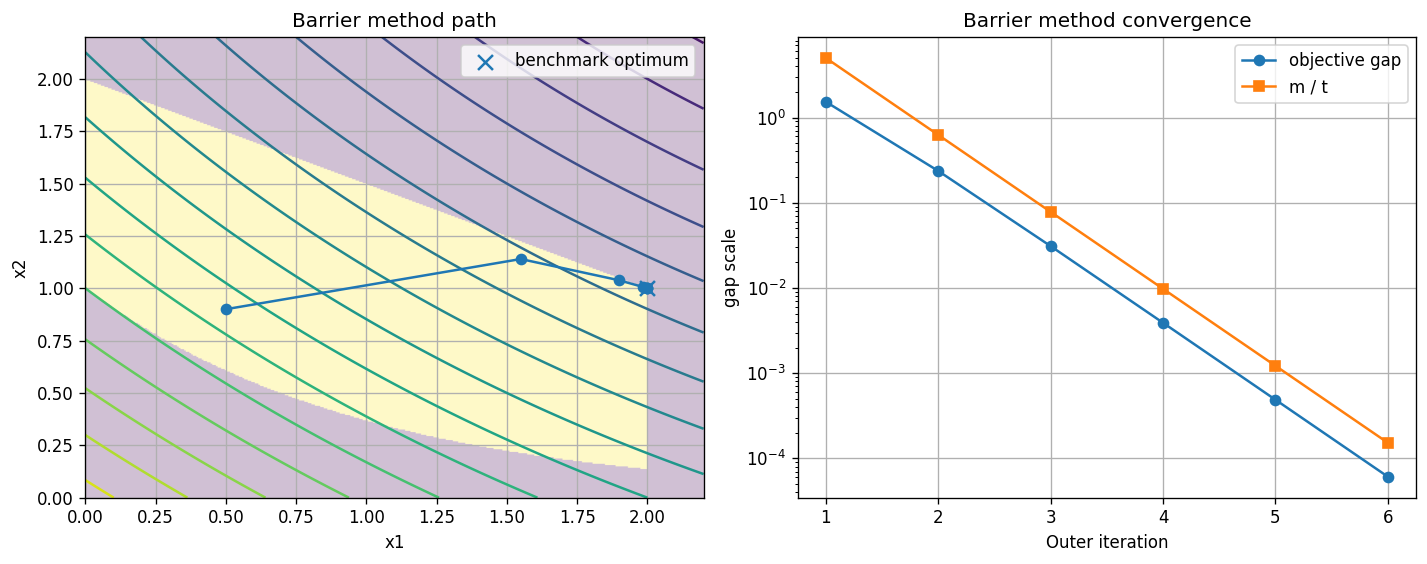

In [21]:
x0_barrier = np.array([0.5, 0.9])
path_barrier, history_barrier = barrier_method_2d(x0_barrier)

print(f"Barrier final iterate: {path_barrier[-1]}")
print(f"Barrier final objective: {objective_2d(path_barrier[-1]):.8f}")
print(f"Distance to benchmark: {np.linalg.norm(path_barrier[-1] - x_2d_benchmark):.3e}")

display(history_barrier)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

axes[0].contour(X, Y, Z, levels=18)
axes[0].imshow(
    feasible_mask.astype(float),
    extent=(X.min(), X.max(), Y.min(), Y.max()),
    origin="lower",
    alpha=0.25,
    aspect="auto",
)
axes[0].plot(path_barrier[:, 0], path_barrier[:, 1], marker="o")
axes[0].scatter([x_2d_benchmark[0]], [x_2d_benchmark[1]], marker="x", s=80, label="benchmark optimum")
axes[0].set_title("Barrier method path")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
axes[0].set_xlim(0, 2.2)
axes[0].set_ylim(0, 2.2)
axes[0].grid(True)
axes[0].legend()

axes[1].plot(history_barrier["outer_iter"], history_barrier["objective"] - value_2d_benchmark, marker="o", label="objective gap")
axes[1].plot(history_barrier["outer_iter"], history_barrier["surrogate_gap"], marker="s", label="m / t")
axes[1].set_yscale("log")
axes[1].set_title("Barrier method convergence")
axes[1].set_xlabel("Outer iteration")
axes[1].set_ylabel("gap scale")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

### Barrier method의 장단점

#### 장점
- 구현이 개념적으로 비교적 단순합니다.
- inequality constraint를 smooth objective 안으로 넣어 Newton machinery를 그대로 재사용할 수 있습니다.
- central path와 $m/t$ surrogate gap이 매우 직관적입니다.

#### 한계
- **strictly feasible start**가 필요합니다.
- 보통은
  - 바깥쪽에서 $t$를 키우는 **outer loop**
  - 안쪽에서 centering problem을 푸는 **inner Newton loop**
  를 동시에 돌려야 하므로 비효율적일 수 있습니다.
- 원본 노트북에서 보였듯이, step size 조절이 없으면 잠시 boundary를 뚫고 나가 버릴 수도 있습니다.

이 비효율을 줄이기 위해 등장하는 것이 바로 **primal-dual interior-point method**입니다.

## Part 4. Primal-dual interior-point method

Barrier method는 각 \(t\)마다 centering subproblem을 거의 다 풀고,  
그 다음 \(t\)를 키우고, 다시 풀고, ... 를 반복합니다.

Primal-dual interior-point method는 이 과정을 좀 더 직접적으로 합니다.

핵심 아이디어는 inequality constraint
$
h(x)\le 0
$
를 slack variable \(s>0\)를 도입해
$
h(x)+s=0
$
로 바꾸고, KKT residual을 한 번에 줄이는 것입니다.

### KKT with slack
$
\begin{aligned}
\nabla f(x) + D h(x)^\top \lambda &= 0,\\
h(x)+s &= 0,\\
S\lambda &= 0,\\
s &> 0,\quad \lambda>0.
\end{aligned}
$

Interior-point에서는 complementarity를 바로 0으로 두지 않고,
$
S\lambda \approx \sigma \mu I,\qquad
\mu = \frac{s^\top \lambda}{m}
$
처럼 둡니다.

### Newton system for primal-dual residual

Residual을
$
r_{\text{dual}} = \nabla f(x)+Dh(x)^\top \lambda,
\qquad
r_{\text{pri}} = h(x)+s,
\qquad
r_{\text{cent}} = S\lambda - \sigma \mu \mathbf{1}
$
로 두면, Newton direction $(\Delta x,\Delta s,\Delta \lambda)$는

$
\begin{bmatrix}
\nabla^2_x L(x,\lambda) & 0 & Dh(x)^\top \\
Dh(x) & I & 0 \\
0 & \Lambda & S
\end{bmatrix}
\begin{bmatrix}
\Delta x \\
\Delta s \\
\Delta \lambda
\end{bmatrix}
= -
\begin{bmatrix}
r_{\text{dual}} \\
r_{\text{pri}} \\
r_{\text{cent}}
\end{bmatrix}
$

를 풀어 얻습니다.

이 식을 보면 중요한 사실이 드러납니다.

- **Part 2의 Newton linear system이 그대로 핵심 블록으로 다시 등장**
- 단지 now slack / dual variable이 추가되어, inequality feasibility와 complementarity까지 동시에 다룬다

즉, primal-dual IPM은 “Newton을 버린 방법”이 아니라,  
오히려 **KKT-Newton을 가장 정교하게 확장한 방법**입니다.

In [22]:
def lagrangian_hessian_2d(x, lam):
    hess = 2.0 * np.eye(2)
    for lam_i, hess_hi in zip(lam, hessian_h_2d_list(x)):
        hess += lam_i * hess_hi
    return hess

def pdip_residual_2d(x, s, lam, sigma=0.1):
    h_values = h_2d(x)
    jacobian = jacobian_h_2d(x)
    m = len(s)
    mu = (s @ lam) / m

    r_dual = gradient_objective_2d(x) + jacobian.T @ lam
    r_pri = h_values + s
    r_cent = s * lam - sigma * mu * np.ones(m)
    return r_dual, r_pri, r_cent, mu

def solve_pdip_direction_2d(x, s, lam, sigma=0.1):
    jacobian = jacobian_h_2d(x)
    hess_lagrangian = lagrangian_hessian_2d(x, lam)
    r_dual, r_pri, r_cent, mu = pdip_residual_2d(x, s, lam, sigma=sigma)
    m = len(s)

    kkt_matrix = np.block(
        [
            [hess_lagrangian, np.zeros((2, m)), jacobian.T],
            [jacobian, np.eye(m), np.zeros((m, m))],
            [np.zeros((m, 2)), np.diag(lam), np.diag(s)],
        ]
    )
    rhs = -np.concatenate([r_dual, r_pri, r_cent])
    solution = np.linalg.solve(kkt_matrix, rhs)

    dx = solution[:2]
    ds = solution[2 : 2 + m]
    dlam = solution[2 + m :]
    return dx, ds, dlam, mu

def primal_dual_interior_point_2d(
    x0, s0, lam0, sigma=0.1, tol=1e-7, max_iter=80, alpha=0.1, beta=0.5
):
    x = x0.copy().astype(float)
    s = s0.copy().astype(float)
    lam = lam0.copy().astype(float)

    path = [x.copy()]
    history_rows = []

    for iteration in range(max_iter):
        r_dual, r_pri, r_cent, mu = pdip_residual_2d(x, s, lam, sigma=sigma)
        residual_vector = np.concatenate([r_dual, r_pri, r_cent])
        residual_norm = np.linalg.norm(residual_vector)

        history_rows.append(
            {
                "iter": iteration,
                "objective": objective_2d(x),
                "mu": mu,
                "residual_norm": residual_norm,
                "x1": x[0],
                "x2": x[1],
            }
        )

        if residual_norm < tol and mu < tol:
            break

        dx, ds, dlam, _ = solve_pdip_direction_2d(x, s, lam, sigma=sigma)

        step = 1.0
        if np.any(ds < 0):
            step = min(step, 0.99 * np.min(-s[ds < 0] / ds[ds < 0]))
        if np.any(dlam < 0):
            step = min(step, 0.99 * np.min(-lam[dlam < 0] / dlam[dlam < 0]))

        while True:
            x_candidate = x + step * dx
            s_candidate = s + step * ds
            lam_candidate = lam + step * dlam

            if np.all(s_candidate > 0) and np.all(lam_candidate > 0):
                r_dual_new, r_pri_new, r_cent_new, _ = pdip_residual_2d(
                    x_candidate, s_candidate, lam_candidate, sigma=sigma
                )
                residual_norm_new = np.linalg.norm(np.concatenate([r_dual_new, r_pri_new, r_cent_new]))
                if residual_norm_new <= (1 - alpha * step) * residual_norm:
                    break

            step *= beta
            if step < 1e-14:
                break

        x = x_candidate
        s = s_candidate
        lam = lam_candidate
        path.append(x.copy())

    history = pd.DataFrame(history_rows)
    return x, s, lam, np.array(path), history

Primal-dual final iterate: [2. 1.]
Primal-dual final objective: 34.00000010
Distance to benchmark: 5.000e-08
Recovered slack vector: [0.     0.8647 0.     2.     1.    ]
Recovered multiplier vector: [0.25 0.   5.   0.   0.  ]


,iter,objective,mu,residual_norm,x1,x2
5,5,34.001024,4.828070e-04,9.813996e-04,1.999431,1.000239
6,6,34.000097,4.843216e-05,9.747078e-05,1.999951,1.000020
7,7,34.000010,4.844309e-06,9.748985e-06,1.999995,1.000002
8,8,34.000001,4.844416e-07,9.749199e-07,2.000000,1.000000
9,9,34.000000,4.844427e-08,9.749221e-08,2.000000,1.000000


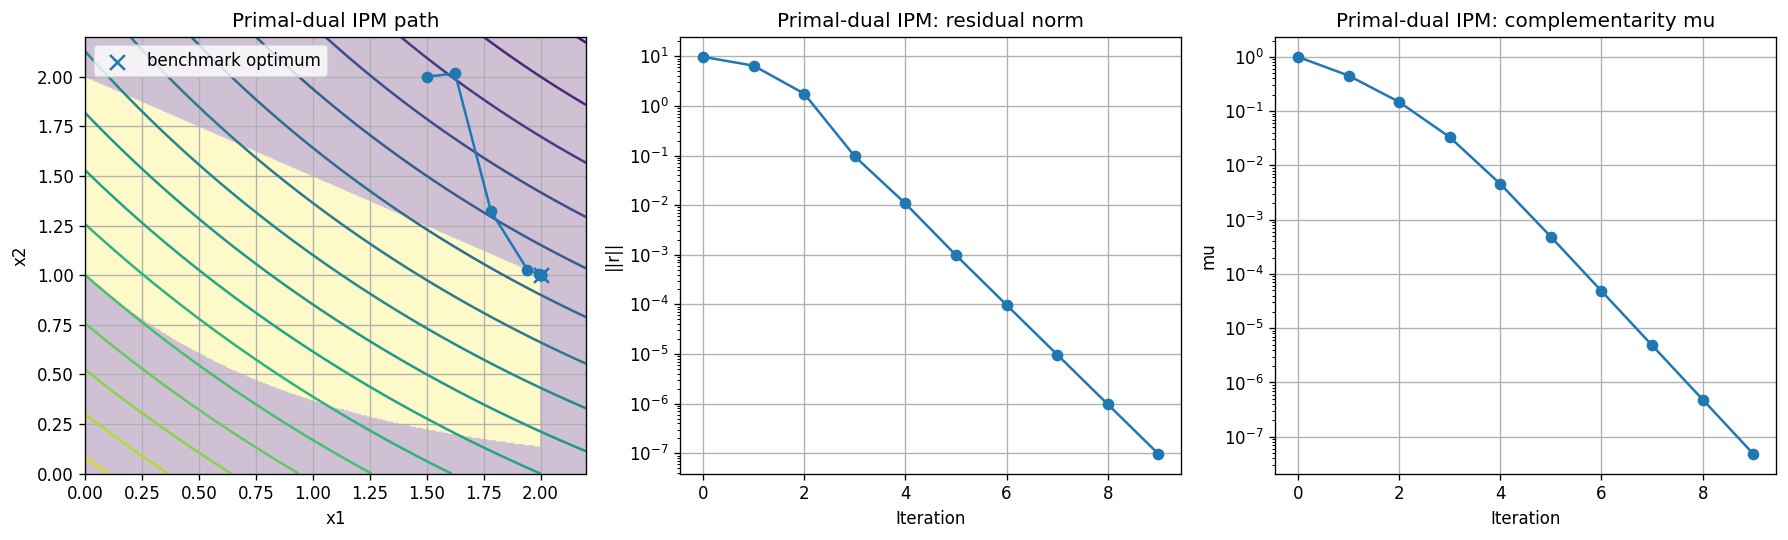

,constraint,cvxpy_dual,pdip_dual
0,x1^2 <= 4,2.500003e-01,2.500000e-01
1,exp(-x1) <= x2,1.790312e-09,5.602659e-08
2,x1 + 2 x2 <= 4,5.000000e+00,5.000000e+00
3,x1 >= 0,2.244175e-10,2.422203e-08
4,x2 >= 0,8.787999e-10,4.844424e-08


In [23]:
x0_pdip = np.array([1.5, 2.0])
s0_pdip = np.ones(5)
lam0_pdip = np.ones(5)

x_pdip, s_pdip, lam_pdip, path_pdip, history_pdip = primal_dual_interior_point_2d(
    x0_pdip, s0_pdip, lam0_pdip
)

print(f"Primal-dual final iterate: {x_pdip}")
print(f"Primal-dual final objective: {objective_2d(x_pdip):.8f}")
print(f"Distance to benchmark: {np.linalg.norm(x_pdip - x_2d_benchmark):.3e}")
print(f"Recovered slack vector: {s_pdip}")
print(f"Recovered multiplier vector: {lam_pdip}")

display(history_pdip.tail())

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))

axes[0].contour(X, Y, Z, levels=18)
axes[0].imshow(
    feasible_mask.astype(float),
    extent=(X.min(), X.max(), Y.min(), Y.max()),
    origin="lower",
    alpha=0.25,
    aspect="auto",
)
axes[0].plot(path_pdip[:, 0], path_pdip[:, 1], marker="o")
axes[0].scatter([x_2d_benchmark[0]], [x_2d_benchmark[1]], marker="x", s=80, label="benchmark optimum")
axes[0].set_title("Primal-dual IPM path")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
axes[0].set_xlim(0, 2.2)
axes[0].set_ylim(0, 2.2)
axes[0].grid(True)
axes[0].legend()

axes[1].plot(history_pdip["iter"], history_pdip["residual_norm"], marker="o")
axes[1].set_title("Primal-dual IPM: residual norm")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("||r||")
axes[1].set_yscale("log")
axes[1].grid(True)

axes[2].plot(history_pdip["iter"], history_pdip["mu"], marker="o")
axes[2].set_title("Primal-dual IPM: complementarity mu")
axes[2].set_xlabel("Iteration")
axes[2].set_ylabel("mu")
axes[2].set_yscale("log")
axes[2].grid(True)

plt.tight_layout()
plt.show()

pdip_vs_cvxpy_duals = pd.DataFrame(
    {
        "constraint": [
            "x1^2 <= 4",
            "exp(-x1) <= x2",
            "x1 + 2 x2 <= 4",
            "x1 >= 0",
            "x2 >= 0",
        ],
        "cvxpy_dual": dual_values_2d,
        "pdip_dual": lam_pdip,
    }
)
display(pdip_vs_cvxpy_duals)

In [24]:
barrier_total_newton_steps = int(history_barrier["inner_newton_steps"].sum())
pdip_total_steps = int(len(history_pdip) - 1)

comparison_part4 = pd.DataFrame(
    [
        {
            "method": "CVXPY benchmark",
            "requires_strict_feasible_start": "No",
            "final_objective": value_2d_benchmark,
            "distance_to_benchmark": 0.0,
            "main_counter": np.nan,
            "comment": "Reference solution"
        },
        {
            "method": "Barrier method",
            "requires_strict_feasible_start": "Yes",
            "final_objective": objective_2d(path_barrier[-1]),
            "distance_to_benchmark": np.linalg.norm(path_barrier[-1] - x_2d_benchmark),
            "main_counter": barrier_total_newton_steps,
            "comment": "Outer-inner structure"
        },
        {
            "method": "Primal-dual IPM",
            "requires_strict_feasible_start": "No",
            "final_objective": objective_2d(x_pdip),
            "distance_to_benchmark": np.linalg.norm(x_pdip - x_2d_benchmark),
            "main_counter": pdip_total_steps,
            "comment": "Residuals and complementarity together"
        },
    ]
)
display(comparison_part4)

,method,requires_strict_feasible_start,final_objective,distance_to_benchmark,main_counter,comment
0,CVXPY benchmark,No,34.000000,0.000000e+00,NaN,Reference solution
1,Barrier method,Yes,34.000061,3.286392e-05,42.0,Outer-inner structure
2,Primal-dual IPM,No,34.000000,5.000103e-08,9.0,Residuals and complementarity together


## Part 5. 한 번에 정리하기

### 1. Duality
dual function은 primal optimum의 **lower bound**를 준다.  
Convex + regularity(Slater)가 있으면 그 lower bound가 종종 **정확한 값**이 된다.

### 2. Equality-constrained Newton
KKT conditions를 선형화하면 나오는 것이 Newton step이다.  
즉, Newton method는 단순한 수치기법이 아니라 **KKT 시스템을 푸는 방법**이다.

### 3. Barrier method
inequality constraint를 \(-\log(-h_i(x))\)로 바꾸어,  
원래 constrained problem을 **일련의 smooth unconstrained-like subproblem**으로 바꾼다.

### 4. Primal-dual interior-point method
barrier의 outer loop와 Newton의 inner loop를 합쳐,  
primal feasibility, dual feasibility, complementarity를 **동시에** 줄인다.

결국 전체 이야기는 다음처럼 이어집니다.

$
\text{duality gap} \;\Rightarrow\; \text{KKT optimality} \;\Rightarrow\; \text{Newton linearization}
\;\Rightarrow\;
\text{barrier path}
\;\Rightarrow\;
\text{primal-dual residual reduction}
$

## 복습 문제와 확장 과제

### 연습문제 1
Part 1의 convex quadratic example에서  
$
\min_x x^2 \quad \text{subject to } x\ge 1
$
의 dual function을 **직접 유도**하고, 왜 $\lambda^\star = 2$인지 설명해 보세요.

### 연습문제 2
Part 2의 analytic centering instance에서 $n$을 40에서 200으로 늘려 보세요.  
feasible-start Newton, infeasible-start Newton, dual Newton의 iteration 수와 conditioning이 어떻게 달라지는지 관찰해 보세요.

### 연습문제 3
Part 3의 barrier method에서 $t_0$, $\mu$, `gap_tol`을 바꿔 보세요.  
outer iteration 수와 inner Newton 횟수의 trade-off가 어떻게 달라지는지 설명해 보세요.

### 연습문제 4
Part 4의 primal-dual IPM에서 $\sigma$를 0.1, 0.3, 0.5로 바꿔 보세요.  
complementarity $\mu$ 감소 속도와 residual 감소 속도 사이의 균형이 어떻게 달라지는지 해석해 보세요.

### 연습문제 5
Barrier method와 primal-dual IPM이 모두 결국 Newton system을 푼다는 사실을 바탕으로,
두 방법의 **공통점**과 **차이점**을 다음 세 축으로 비교해 보세요.

1. feasibility handling  
2. stopping criterion  
3. computational structure

---
